**Architecture**

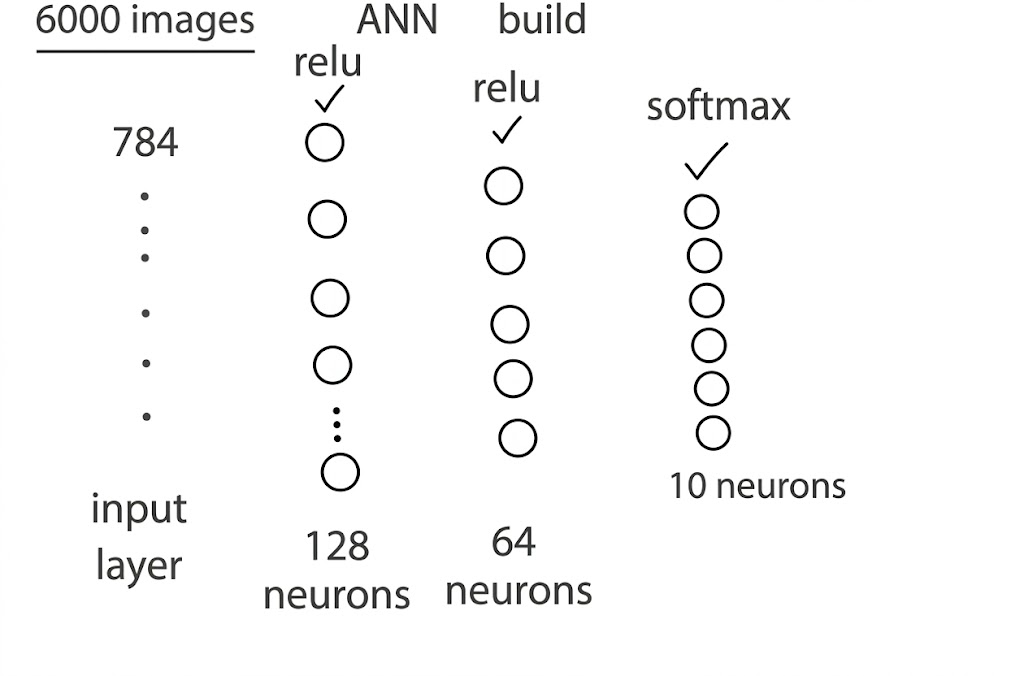

In [ ]:
from torch.cuda import is_available, get_device_name

if is_available():
    print("its available")
else:
    print("not available")

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

its available
cuda


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,roc_curve
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
from matplotlib import pyplot as plt


In [ ]:
torch.manual_seed(42)

**Using GPUs**
from Runtime, select change run time type  selecting TPUs

In [ ]:
#df =pd.read_csv('fmnist_small.csv') trained woth CPUs
df =pd.read_csv('fashion-mnist_train.csv')

In [ ]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125,72,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,210,228,228,233,0,0,0,0,0,0,0,0,0,31,81,133,184,201,190,117,0,0,2,1,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,43,117,34,15,24,33,117,80,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,51,144,152,...,157,158,161,148,159,58,0,6,0,0,0,0,0,0,0,0,0,4,0,60,143,143,148,146,152,152,148,148,147,145,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,0,0,0,2,0,33,114,37,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,11,17,13,13,11,10,7,5,5,5,7,0,0,0,1,0,0,41,69,88,86,94,106,114,118,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,0,2,0,58,145,114,10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,...,165,153,155,134,143,172,215,62,0,0,0,0,0,0,0,0,10,190,178,194,209,211,209,205,211,215,213,217,225,228,213,203,174,151,188,10,0,0,0,0


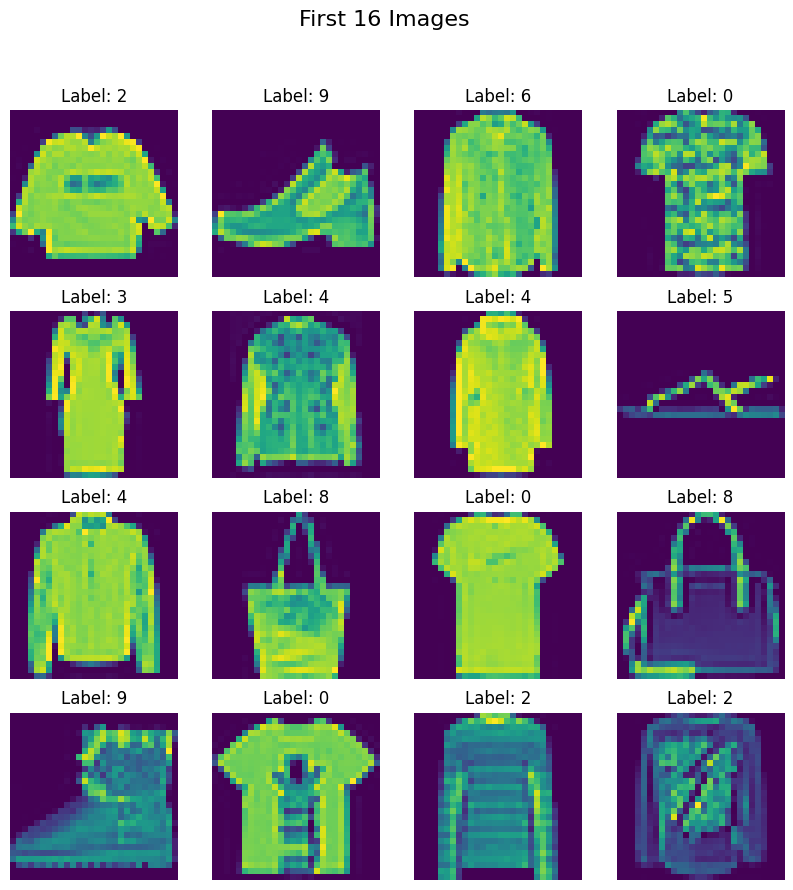

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
#fig size defines the wodth and height in inches
# 4,4 it says there are 16 images with 4 rows and 4 columns
#Fig defines entire row and axis for each images in grid of 4*4.
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Renders the 2D array as an image.
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

In [ ]:
# train test split

X = df.iloc[:, 1:].values # it extracts as array
y = df.iloc[:, 0].values

In [ ]:
x_train,x_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(len(x_test))
print(len(y_test))

12000
12000


In [ ]:
#Scaling the variable , SInce image has value from 0 to 256 and we need to standardized before
x_train_scaled=x_train/255
x_test_scaled=x_test/255

In [ ]:
#Create Custom Dataset class

class CustomDataset(Dataset):
  def __init__(self,x,y):
    self.x=torch.tensor(x,dtype=torch.float32)
    self.y=torch.tensor(y,dtype=torch.long)

  def __len__(self):
    return len(self.x)

  def __getitem__(self,index):
    return self.x[index],self.y[index]


In [ ]:
train_dataset=CustomDataset(x_train_scaled,y_train)
test_dataset=CustomDataset(x_test_scaled,y_test)

In [ ]:
len(train_dataset)

48000

In [ ]:
## Creating data Loader
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory= True) # batch size should be 32, 64,128,256 or 512 : will use 128
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True) # shuffle flase because we want to test for every sample

In [ ]:
# Creating NN class

class Model(nn.Module):
  def __init__(self,input_features):
    super(Model,self).__init__()
    self.fc1=nn.Linear(input_features.shape[1],128)
    self.relu1=nn.ReLU()
    self.fc2=nn.Linear(128,64)
    self.relu2=nn.ReLU()
    self.fc3=nn.Linear(64,10)
    #self.sigmoid=nn.Softmax() # by default Pytorch ends with softmax so we should not assign else it will be doing softmax twice

  def forward(self,x):
    out=self.fc1(x)
    out=self.relu1(out)
    out=self.fc2(out)
    out=self.relu2(out)
    out=self.fc3(out)
    return out


In [ ]:
#Setting Parameter
epoch=100
learning_rate=0.1

In [ ]:
#Instanciating the model
model=Model(x_train_scaled)
model=model.to(device) # Shipping to CUDA device
#Loss
criterion=nn.CrossEntropyLoss()

#Optimizer
optimizer=optim.SGD(model.parameters(),lr=learning_rate)

In [ ]:
!pip install torchinfo
from torchinfo import summary
summary(model,input_size=(32,x_train_scaled.shape[1])) # it has paramter( batch_size , # of feature)

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [32, 10]                  --
├─Linear: 1-1                            [32, 128]                 100,480
├─ReLU: 1-2                              [32, 128]                 --
├─Linear: 1-3                            [32, 64]                  8,256
├─ReLU: 1-4                              [32, 64]                  --
├─Linear: 1-5                            [32, 10]                  650
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.50
Input size (MB): 0.10
Forward/backward pass size (MB): 0.05
Params size (MB): 0.44
Estimated Total Size (MB): 0.59

In [ ]:
#Training pipeline

for epoch in range(epoch):
  total_epch_loss=0
  for x,y  in train_loader:
    #Move to GPUs
    x,y=x.to(device),y.to(device) # moving to GPUS then reassignig to x & Y

    # forward
    y_pred=model(x)
    loss=criterion(y_pred,y)
    total_epch_loss+=loss.item()
    #backward
    optimizer.zero_grad()
    loss.backward()

    #update
    optimizer.step()
  print(f"Epoch: {epoch+1}, Loss: {total_epch_loss/len(train_loader)}")

Epoch: 1, Loss: 0.6410169772803783
Epoch: 2, Loss: 0.4311366136918465
Epoch: 3, Loss: 0.3842576188594103
Epoch: 4, Loss: 0.3586971324582895
Epoch: 5, Loss: 0.34093022284656765
Epoch: 6, Loss: 0.3212974127084017
Epoch: 7, Loss: 0.30779544831067324
Epoch: 8, Loss: 0.2935433429852128
Epoch: 9, Loss: 0.28700923292835556
Epoch: 10, Loss: 0.27428549756482246
Epoch: 11, Loss: 0.2665667013252775
Epoch: 12, Loss: 0.2592154320118328
Epoch: 13, Loss: 0.2520451021144787
Epoch: 14, Loss: 0.2460923679570357
Epoch: 15, Loss: 0.2384296647235751
Epoch: 16, Loss: 0.23058066341653466
Epoch: 17, Loss: 0.22509638437256216
Epoch: 18, Loss: 0.21995875553786753
Epoch: 19, Loss: 0.21662484349062044
Epoch: 20, Loss: 0.21216669666208327
Epoch: 21, Loss: 0.20551405793925126
Epoch: 22, Loss: 0.2018692177878693
Epoch: 23, Loss: 0.19805065332042673
Epoch: 24, Loss: 0.19443898941328128
Epoch: 25, Loss: 0.18906510828000803
Epoch: 26, Loss: 0.18515762419626117
Epoch: 27, Loss: 0.18275832775856057
Epoch: 28, Loss: 0.180


When you call **model.eval()**, you are telling PyTorch to switch the model from Training mode to Evaluation (Inference) mode.

This is a critical step before you test your model on new data or calculate validation accuracy. It doesn't change the weights, but it changes how specific layers behave.

**Why is it necessary?**

Some layers work differently depending on whether you are teaching the model or using it to make predictions. The two biggest examples are:

**Dropout Layers: **During training, Dropout randomly "shuts off" neurons to prevent overfitting. In evaluation mode, Dropout is disabled so the model uses its full power to give a consistent answer.

**Batch Normalization:** During training, these layers calculate mean and variance based on the current batch. In evaluation mode, they stop calculating new statistics and use the "running" averages they learned during training.

**The Golden Rule: Use it with torch.no_grad()**

While model.eval() handles layer behavior, it does not stop PyTorch from calculating gradients (which consumes a lot of memory). To make your testing fast and efficient, always wrap your evaluation code like this:

**Python**

model.eval()  # Switch to eval mode
with torch.no_grad():  # Disable gradient calculation
    predictions = model(x_test)
    # Calculate accuracy here...
What happens if you forget it?
If you forget model.eval(), your test results will be inconsistent. Because Dropout remains active, the model will randomly ignore parts of its brain every time you ask it a question, leading to slightly different (and usually worse) results for the same input.

In [ ]:
model.eval() # why its required ,

Model(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

**torch.max(outputs, 1)**

outputs: This is the 2D tensor coming out of your model. Its shape is [Batch Size, 10].

1: This is the dimension (axis) to search across.

dim=0 would look for the max value vertically (across all images).

dim=1 looks horizontally (across the 10 class scores for a single image).

The "Double Return"
One unique thing about torch.max in PyTorch is that it returns two things at once as a tuple:

The Values: The actual highest probability/score found (e.g., 0.98).

The Indices: The location (index) where that max value was found. Since our indices are 0, 1, 2... up to 9, the index is exactly the digit the model is predicting.

In [ ]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels=batch_features.to(device),batch_labels.to(device) # moving to GPUS then reassignig to x & Y

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

#without CUDA: Accuracy :0.851

0.8876666666666667


**How To improvise the Accuracy:**


1.   Load the entire data using GPUs
2.   Use different optimizer(RMS prop or ADAM)
3.   Use different learning parameter and epoch
4. use different way of weight initilization
5. use different DropOut and and batch normalization
6. change the model architecture.



